In [2]:
import torch
import torch.nn.functional as F

def scaled_dot_product_attention(Q, K, V):
    """
    Implementazione della formula: softmax( (Q @ K.T) / sqrt(d_k) ) @ V
    """
    # Prendiamo la dimensione d_k (la dimensione delle chiavi/vettori)
    # Q ha forma (batch_size, num_tokens, d_k)
    d_k = Q.size(-1)
    
    # Passo A: Q K^T (Prodotto scalare per calcolare l'affinità)
    # Usiamo transpose(-2, -1) per invertire le ultime due dimensioni di K
    scores = torch.matmul(Q, K.transpose(-2, -1))
    
    # Passo B: Diviso sqrt(d_k) (Lo scalamento)
    scores = scores / (d_k ** 0.5)
    
    # Passo C: Softmax (Normalizzazione per ottenere i pesi dell'attenzione)
    # Applichiamo la softmax sull'ultima dimensione (le colonne della matrice dei punteggi)
    attention_weights = F.softmax(scores, dim=-1)
    
    # Passo D: Moltiplicazione per V (Media ponderata dei valori)
    output = torch.matmul(attention_weights, V)
    
    return output, attention_weights

In [3]:
# Fissiamo il seed per avere risultati riproducibili
torch.manual_seed(42)

batch_size = 1
num_tokens = 4  # Numero di patch dell'immagine
d_k = 3          # Dimensione di Query e Key
d_v = 3          # Dimensione di Value

# Generiamo matrici casuali per Q, K, V
Q = torch.randn(batch_size, num_tokens, d_k)
K = torch.randn(batch_size, num_tokens, d_k)
V = torch.randn(batch_size, num_tokens, d_v)

print("Matrice Query (Q):\n", Q.squeeze(0))
print("\nMatrice Key (K):\n", K.squeeze(0))
print("\nMatrice Value (V):\n", V.squeeze(0))

Matrice Query (Q):
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617],
        [ 0.2674,  0.5349,  0.8094]])

Matrice Key (K):
 tensor([[ 1.1103, -1.6898, -0.9890],
        [ 0.9580,  1.3221,  0.8172],
        [-0.7658, -0.7506,  1.3525],
        [ 0.6863, -0.3278,  0.7950]])

Matrice Value (V):
 tensor([[ 0.2815,  0.0562,  0.5227],
        [-0.2384, -0.0499,  0.5263],
        [-0.0085,  0.7291,  0.1331],
        [ 0.8640, -1.0157, -0.8887]])


In [4]:
# Eseguiamo il meccanismo di attenzione
output, weights = scaled_dot_product_attention(Q, K, V)

print("--- MATRICE DEI PESI DELL'ATTENZIONE (Dopo la Softmax) ---")
# Ogni riga i rappresenta la patch 'i' che guarda tutte le patch 'j' (colonne)
print(weights.squeeze(0))

print("\n--- OUTPUT FINALE (Rappresentazione arricchita del contesto) ---")
print(output.squeeze(0))

--- MATRICE DEI PESI DELL'ATTENZIONE (Dopo la Softmax) ---
tensor([[0.2053, 0.3184, 0.2099, 0.2664],
        [0.5661, 0.0648, 0.1865, 0.1826],
        [0.4700, 0.2065, 0.0568, 0.2667],
        [0.0767, 0.4419, 0.2293, 0.2520]])

--- OUTPUT FINALE (Rappresentazione arricchita del contesto) ---
tensor([[ 0.2103, -0.1219,  0.0661],
        [ 0.3001, -0.0210,  0.1925],
        [ 0.3130, -0.2134,  0.1250],
        [ 0.1320, -0.1065,  0.0793]])


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)
    weights = F.softmax(scores, dim=-1)
    output = torch.matmul(weights, V)
    return output, weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, h):
        """
        d_model : dimensione totale del modello (es. 512 in "Attention is All You Need")
        h       : numero di teste (heads)
        
        Ogni head lavora su uno spazio di dimensione d_k = d_v = d_model / h
        """
        super().__init__()
        assert d_model % h == 0, "d_model deve essere divisibile per h"
        
        self.h = h
        self.d_model = d_model
        self.d_k = d_model // h  # dimensione per ogni head
        
        # Le matrici W_i^Q, W_i^K, W_i^V per tutte le h teste
        # Le implementiamo come un'unica proiezione lineare (più efficiente)
        self.W_Q = nn.Linear(d_model, d_model)  # = h * d_k
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        
        # La matrice W^O finale: Concat(head_1...head_h) -> d_model
        self.W_O = nn.Linear(d_model, d_model)
    
    def split_heads(self, x):
        """
        Trasforma (batch, seq_len, d_model) → (batch, h, seq_len, d_k)
        separando le h teste lungo una dimensione dedicata
        """
        batch_size, seq_len, d_model = x.size()
        x = x.view(batch_size, seq_len, self.h, self.d_k)
        return x.transpose(1, 2)  # (batch, h, seq_len, d_k)
    
    def forward(self, Q, K, V):
        batch_size = Q.size(0)
        
        # Passo 1: Proiezione lineare e split in h teste
        # headi = Attention(Q W_i^Q, K W_i^K, V W_i^V)
        Q = self.split_heads(self.W_Q(Q))  # (batch, h, seq_len, d_k)
        K = self.split_heads(self.W_K(K))
        V = self.split_heads(self.W_V(V))
        
        # Passo 2: Scaled Dot-Product Attention per ogni head in parallelo
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V)
        # attn_output: (batch, h, seq_len, d_k)
        
        # Passo 3: Concat(head_1, ..., head_h)
        # (batch, h, seq_len, d_k) → (batch, seq_len, h * d_k) = (batch, seq_len, d_model)
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(batch_size, -1, self.d_model)
        
        # Passo 4: Proiezione finale W^O
        output = self.W_O(attn_output)
        
        return output, attn_weights


Shape input:          torch.Size([1, 5, 8])
Shape output:         torch.Size([1, 5, 8])
Shape attn_weights:   torch.Size([1, 2, 5, 5])


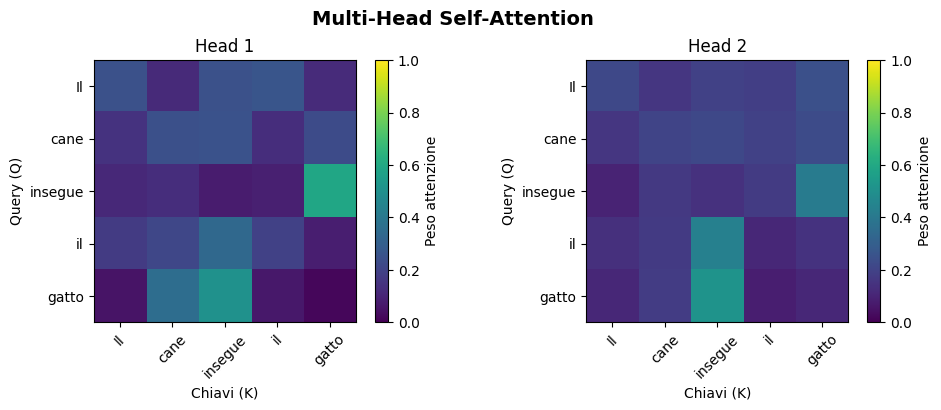

In [11]:
import matplotlib.pyplot as plt

torch.manual_seed(42)

# --- Iperparametri ---
d_model = 8   # dimensione embedding totale
h       = 2   # numero di teste
# → ogni head lavora su d_k = 8/2 = 4 dimensioni

words  = ["Il", "cane", "insegue", "il", "gatto"]
num_tokens = len(words)

# Input: sequenza di token con embedding casuale (ma riproducibile)
X = torch.randn(1, num_tokens, d_model)  # (batch=1, seq=5, d_model=8)

# Inizializziamo e eseguiamo il modello
mha = MultiHeadAttention(d_model=d_model, h=h)
output, attn_weights = mha(X, X, X)  # Self-Attention: Q=K=V=X

print(f"Shape input:          {X.shape}")          # (1, 5, 8)
print(f"Shape output:         {output.shape}")     # (1, 5, 8)
print(f"Shape attn_weights:   {attn_weights.shape}")  # (1, h=2, 5, 5)

# --- Visualizzazione: una heatmap per ogni head ---
fig, axes = plt.subplots(1, h, figsize=(5 * h, 4))

for i in range(h):
    ax = axes[i]
    matrix = attn_weights[0, i].detach().numpy()  # (seq, seq) per la testa i
    im = ax.imshow(matrix, cmap='viridis', vmin=0, vmax=1)
    ax.set_xticks(range(num_tokens)); ax.set_xticklabels(words, rotation=45)
    ax.set_yticks(range(num_tokens)); ax.set_yticklabels(words)
    ax.set_title(f"Head {i+1}")
    ax.set_xlabel("Chiavi (K)")
    ax.set_ylabel("Query (Q)")
    plt.colorbar(im, ax=ax, label="Peso attenzione")

plt.suptitle("Multi-Head Self-Attention", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
